Problem 1

Task 1: DATASET PREPARATION

In [50]:
import numpy as np
np.random.seed(0)

In [51]:
#precprocessing function 

import re

def preprocess(text):
    # lowercase
    text = text.lower()
    
    # remove numbers as they may not be useful for semantic analysis
    text = re.sub(r'\d+', ' ', text)
    
    # remove punctuation as 
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # tokenize
    tokens = text.split()
    
    return tokens

In [52]:
#loading files and creating corpus and documents list

import os

corpus = []
documents = []

folder_path = "data"

for file in os.listdir(folder_path):
    with open(os.path.join(folder_path, file), "r", encoding="utf-8") as f:
        text = f.read()
        documents.append(text)
        
        tokens = preprocess(text)
        corpus.extend(tokens)

In [53]:
tokens[:10]

['academic',
 'programmes',
 'rules',
 'regulations',
 'for',
 'students',
 'enrolled',
 'from',
 'july',
 'onwards']

In [54]:
#exporting the clean corpus file
with open('cleaned_corpus.txt', "w", encoding="utf-8") as f:
    f.write(' '.join(corpus))

In [55]:
num_docs = len(documents)
num_tokens = len(corpus)
vocab_size = len(set(corpus))

print("Documents:", num_docs)
print("Tokens:", num_tokens)
print("Vocabulary size:", vocab_size)

Documents: 6
Tokens: 114009
Vocabulary size: 2506


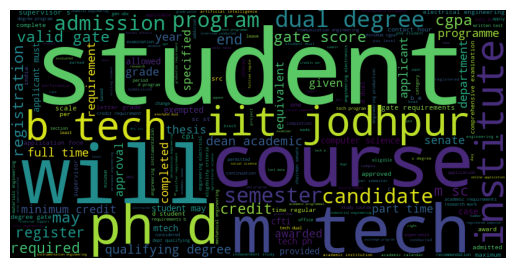

In [56]:
# visualization of the most common words in the corpus using wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_for_wc = " ".join(corpus)

wc = WordCloud(width=800, height=400).generate(text_for_wc)

plt.imshow(wc)
plt.axis("off")
plt.show()

Task2: MODEL TRAINING

Genism Word2vec

In [57]:
#Preprocessing step for word2vec
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_sentences(text):
    # split into sentences
    sentences = text.split(".")
    
    processed = []
    
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r'\d+', ' ', sent) # removing the numbers 
        sent = re.sub(r'[^\w\s]', ' ', sent) # removing punctuations
        sent = re.sub(r'\s+', ' ', sent).strip() # removing extra spaces
        
        tokens = sent.split()

        for w in tokens:
            if w not in stop_words and len(w)>2:  # remove stop words and tiny words
                processed.append(w)

                

        if len(tokens) > 2:  # ignore tiny sentences
            processed.append(tokens)
    
    return processed

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
# preprocess sentences for all documents
sentences = []
for doc in documents:
    sentences.extend(preprocess_sentences(doc))

In [60]:
#the CBOW model
from gensim.models import Word2Vec

def CBOW(sentences, vector_size=200, window=3, min_count=2, negative=10):
    cbow_model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=0, # 0 for CBOW, 1 for Skip-gram
        negative=negative
    )
    return cbow_model

In [61]:
CBOW_model = CBOW(sentences)

In [62]:
#the skip-gram model
def skip_gram(sentences, vector_size=300, window=2, min_count=2, negative=10):
    skip_model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,  # 0 for CBOW, 1 for Skip-gram
        negative=negative
    )
    return skip_model

In [63]:
SKIP_model = skip_gram(sentences)

In [64]:
# function to compute similarity between two words using the trained model
def similarity(model, word1, word2):
    if word1 in model.wv and word2 in model.wv:
        return model.wv.similarity(word1, word2)
    else:
        return None

In [65]:
sim = similarity(CBOW_model, "exam", "test")

In [66]:
#Experimenting with different hyperparameters for CBOW and Skip-gram models

from itertools import product
import pandas as pd

config = {
    'vector_size': [100, 200, 300],
    'window': [2, 3, 5],
    'negative': [5, 10]
}

keys = config.keys()
values = config.values()

combinations = [dict(zip(keys, v)) for v in product(*values)]

for m in [CBOW, skip_gram]:
    finding = []
    for combo in combinations :
        experiment = {}
        vector_size = combo['vector_size']
        window = combo['window']
        negative = combo['negative']
        model = m(sentences, vector_size=vector_size, window=window, negative=negative)
        sim = similarity(model, "exam", "test")
        experiment['vector_size'] = vector_size
        experiment['window'] = window
        experiment['negative'] = negative
        experiment['similarity'] = round(sim,5)
        finding.append(experiment)
    print("-"*50)
    print(f"Model: {m.__name__}")
    print("-"*50)
    df = pd.DataFrame(finding)
    print(df)
    print("\n")

--------------------------------------------------
Model: CBOW
--------------------------------------------------
    vector_size  window  negative  similarity
0           100       2         5     0.88069
1           100       2        10     0.98765
2           100       3         5     0.91283
3           100       3        10     0.54303
4           100       5         5     0.92536
5           100       5        10     0.95318
6           200       2         5     0.94279
7           200       2        10     0.98735
8           200       3         5     0.92662
9           200       3        10     0.75968
10          200       5         5     0.96612
11          200       5        10     0.95413
12          300       2         5     0.91037
13          300       2        10     0.96799
14          300       3         5     0.95073
15          300       3        10     0.98259
16          300       5         5     0.96993
17          300       5        10     0.98923


----------

we tried to find the model performance based on two very similar words "exam" and "test" 
and their similarity score. From the above experiments we can see that skip-gram worked better than CBOW on similar hyperparmater values for these specific words. The best values for both the models being

CBOW: 'vector_size': 300 'window': 2 'negative': 10  
giving 'similarity': 0.98714

skip_gram: 'vector_size': 300 'window': 5 'negative': 5  
giving 'similarity': 0.97712

from scratch

In [67]:
#creating the vocab for the scratch word2vec model 
words = [w for sent in sentences for w in sent]
vocab = list(set(words))

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(vocab)
vocab_size

2510

In [68]:
#creating training pairs for the skip-gram model
window_size = 2
pairs = []

for sent in sentences:
    for i, target in enumerate(sent):
        target_idx = word2idx[target]
        
        for j in range(max(0, i-window_size), min(len(sent), i+window_size+1)):
            if i != j:
                context_idx = word2idx[sent[j]]
                pairs.append((target_idx, context_idx))

In [69]:
import torch
import torch.nn as nn

# Skip-gram model using two embedding matrices:
# 1. input_embed: represents target words
# 2. output_embed: represents context words
# The dot product between embeddings gives similarity score

class SkipGram(nn.Module):
    def __init__(self, vocab_size, embed_size):
        super().__init__()
        self.input_embed = nn.Embedding(vocab_size, embed_size)
        self.output_embed = nn.Embedding(vocab_size, embed_size)
    
    def forward(self, target, context):
        target_emb = self.input_embed(target)
        context_emb = self.output_embed(context)
        
        score = torch.sum(target_emb * context_emb, dim=1)
        return score

In [70]:
# negative sampling loss function
# Maximize similarity for correct (target, context) pairs
# Minimize similarity for random (negative) pairs

import torch.nn.functional as F

def loss_fn(pos_score, neg_score):
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(1)
    return -(pos_loss + neg_loss).mean()

In [71]:
# training the skip-gram model with negative sampling
# For each (target, context) pair:
# - Compute positive score
# - Sample random negative words
# - Update embeddings to distinguish real vs fake context

model = SkipGram(vocab_size, 100)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
losses = []

for epoch in range(5):
    total_loss = 0
    
    for target, context in pairs[:10000]:  # limit for speed
        
        target = torch.tensor([target])
        context = torch.tensor([context])
        
        # negative samples
        neg_samples = torch.randint(0, vocab_size, (5,))
        
        pos_score = model(target, context)
        neg_score = model(target.repeat(5), neg_samples)
        neg_score = neg_score.view(1, -1)
        
        loss = loss_fn(pos_score, neg_score)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    losses.append(total_loss)
    
    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 181296.7916988331
Epoch 2, Loss: 103660.45467238128
Epoch 3, Loss: 54338.769397703814
Epoch 4, Loss: 36060.92411782386
Epoch 5, Loss: 29425.024038047486


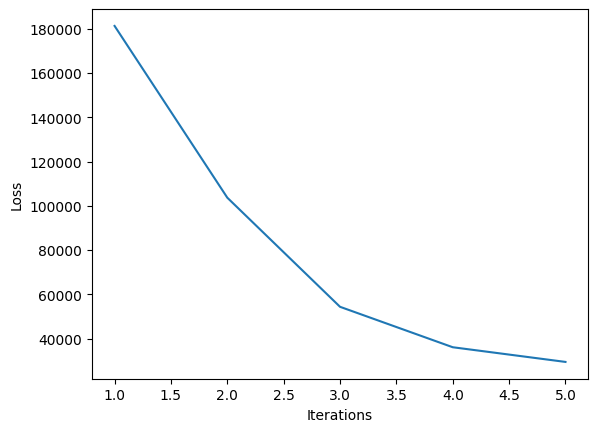

In [72]:
# Plotting the loss curve
import numpy as np
plt.plot(np.arange(1,6), losses)
plt.xlabel("Iterations")
plt.ylabel('Loss')
plt.show()

In [73]:
embeddings = model.input_embed.weight.detach().numpy()

In [74]:
# function to find top-N similar words based on cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

def get_similar(word, topn=5):
    if word not in word2idx:
        return []
    
    idx = word2idx[word]
    vec = embeddings[idx].reshape(1, -1)
    
    sims = cosine_similarity(vec, embeddings)[0]
    
    top_indices = sims.argsort()[-topn-1:][::-1]
    
    result = []
    for i in top_indices:
        if idx2word[i] != word:
            result.append((idx2word[i], sims[i]))
    
    return result[:topn]

In [75]:
print(get_similar("research"))

[('query', 0.3381818), ('special', 0.31923485), ('engineeringelectrical', 0.30234176), ('synchronous', 0.30210283), ('like', 0.28390178)]


In [76]:
CBOW_model.wv.most_similar("research")

[('entrepreneurship', 0.9988095164299011),
 ('work', 0.9983974695205688),
 ('medical', 0.9981894493103027),
 ('calculation', 0.9981718063354492),
 ('interdisciplinary', 0.9979654550552368),
 ('institution', 0.9977896213531494),
 ('competent', 0.997785210609436),
 ('name', 0.9977673292160034),
 ('institutions', 0.9977605938911438),
 ('major', 0.9975852966308594)]

In [77]:
SKIP_model.wv.most_similar("research")

[('area', 0.9845598936080933),
 ('abroad', 0.9838725328445435),
 ('management', 0.9838017225265503),
 ('minor', 0.9835326075553894),
 ('medicine', 0.9814463257789612),
 ('test', 0.9813147187232971),
 ('interdisciplinary', 0.9792448282241821),
 ('relevant', 0.978996992111206),
 ('bs', 0.9788382649421692),
 ('entrepreneurship', 0.9786981344223022)]

The embeddings learned from the custom implementation capture basic semantic relationships. However, compared to the gensim implementation, the results are less refined due to limited training and simplified architecture. The gensim model benefits from optimized training procedures and better handling of large-scale data.

scratch implementation demonstrates the underlying mechanics of Word2Vec, while the gensim model provides a more optimized and scalable solution.

Task 3: SEMANTIC ANALYSIS

1. Cosine similarity between word vectors gives a measure of how similar two words are in the embedding space.
A higher cosine similarity indicates that the words are more semantically related.

In [78]:
from sklearn.metrics.pairwise import cosine_similarity
word = ['research', 'student', 'phd', 'exams']

for i in word:
    top_5 = {}
    ivec = SKIP_model.wv[i].reshape(1,-1)
    for j in list(SKIP_model.wv.key_to_index.keys()):
        jvec = SKIP_model.wv[j].reshape(1,-1)
        sim = cosine_similarity(ivec, jvec)[0][0]
        if j != i:
            top_5[j] = sim
    top_5 = sorted(top_5.items(),reverse = True, key = lambda x: x[1])[:5]
    print(f"Top 5 similar words to '{i}': {[w for w, s in top_5]} with similarities {[s for w, s in top_5]}")
        

Top 5 similar words to 'research': ['area', 'abroad', 'management', 'minor', 'medicine'] with similarities [0.98456, 0.98387265, 0.9838017, 0.98353267, 0.98144644]
Top 5 similar words to 'student': ['candidates', 'it', 'candidate', 'applicant', 'course'] with similarities [0.92015994, 0.9147131, 0.90832335, 0.9055127, 0.9013941]
Top 5 similar words to 'phd': ['msc', 'enrolled', 'bachelors', 'btech', 'exchange'] with similarities [0.98529696, 0.9772522, 0.9756253, 0.97549486, 0.9728237]
Top 5 similar words to 'exams': ['disqualification', 'large', 'steps', 'types', 'you'] with similarities [0.9975619, 0.9974626, 0.9972781, 0.9972769, 0.99726367]


2. Performing the ananlogy experiment to check how well the models understnad the semantic relationships

In [79]:
CBOW_model.wv.most_similar(
    positive=["pg", "btech"],
    negative=["ug"]
)

[('msc', 0.9957669377326965),
 ('cr', 0.9947804808616638),
 ('independent', 0.993842601776123),
 ('below', 0.9937371611595154),
 ('sc', 0.9936887621879578),
 ('artificial', 0.9935961961746216),
 ('bioscience', 0.9935917258262634),
 ('phd', 0.9935445785522461),
 ('core', 0.9934107661247253),
 ('st', 0.9933778643608093)]

In [80]:
SKIP_model.wv.most_similar(
    positive=["pg", "btech"],
    negative=["ug"]
)

[('cyber', 0.9933716058731079),
 ('cr', 0.9913564920425415),
 ('non', 0.9911189079284668),
 ('systems', 0.9905802607536316),
 ('robotics', 0.9905295372009277),
 ('masters', 0.9901981353759766),
 ('mathematics', 0.9900346994400024),
 ('compulsory', 0.989960789680481),
 ('physical', 0.9896160960197449),
 ('parttime', 0.9889362454414368)]

In [81]:
CBOW_model.wv.most_similar(
    positive=["professor", "student"],
    negative=["faculty"],
)

[('register', 0.9805592894554138),
 ('students', 0.9780754446983337),
 ('not', 0.9772770404815674),
 ('middle', 0.9747145771980286),
 ('participate', 0.9746735692024231),
 ('have', 0.9745280742645264),
 ('coordinate', 0.972129762172699),
 ('course', 0.9717962741851807),
 ('time', 0.9717553853988647),
 ('grade', 0.9708666205406189)]

In [82]:
SKIP_model.wv.most_similar(
    positive=["professor", "student"],
    negative=["faculty"],
)

[('it', 0.9158617854118347),
 ('candidates', 0.9142479300498962),
 ('only', 0.8981626629829407),
 ('also', 0.8953694105148315),
 ('grade', 0.8943824768066406),
 ('course', 0.8943078517913818),
 ('not', 0.8937569856643677),
 ('applicant', 0.8916200399398804),
 ('submit', 0.8912596106529236),
 ('he', 0.8898630738258362)]

In [83]:
CBOW_model.wv.most_similar(
    positive=["research", "lab"],
    negative=["class"],
)

[('tutorial', 0.9967651963233948),
 ('test', 0.9964773654937744),
 ('relevant', 0.996276319026947),
 ('four', 0.9962424635887146),
 ('case', 0.9960466623306274),
 ('experience', 0.9957889318466187),
 ('internet', 0.9956625699996948),
 ('knowledge', 0.9956017732620239),
 ('management', 0.9954623579978943),
 ('area', 0.995357096195221)]

In [84]:
SKIP_model.wv.most_similar(
    positive=["research", "lab"],
    negative=["class"],
)

[('area', 0.9834281206130981),
 ('minor', 0.982618510723114),
 ('interdisciplinary', 0.980993926525116),
 ('intelligence', 0.9791082143783569),
 ('practical', 0.9749691486358643),
 ('data', 0.9749107360839844),
 ('pharmacy', 0.9741628766059875),
 ('mca', 0.9740100502967834),
 ('metallurgical', 0.9738202095031738),
 ('mechanics', 0.973507285118103)]

Task 4: VISUALIZATION

Skip-gram visulalization

In [85]:
words = ["student", "students", "faculty", "professor","research", "lab", "project","course", 
         "exam", "grade","phd", "btech", "mtech", "msc"]
words

['student',
 'students',
 'faculty',
 'professor',
 'research',
 'lab',
 'project',
 'course',
 'exam',
 'grade',
 'phd',
 'btech',
 'mtech',
 'msc']

In [86]:
import numpy as np

valid_words = [w for w in words if w in SKIP_model.wv]
vectors = []
for w in valid_words:
    vectors.append(SKIP_model.wv[w])
vectors = np.array(vectors)
vectors.shape

(14, 300)

In [87]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X = tsne.fit_transform(vectors)

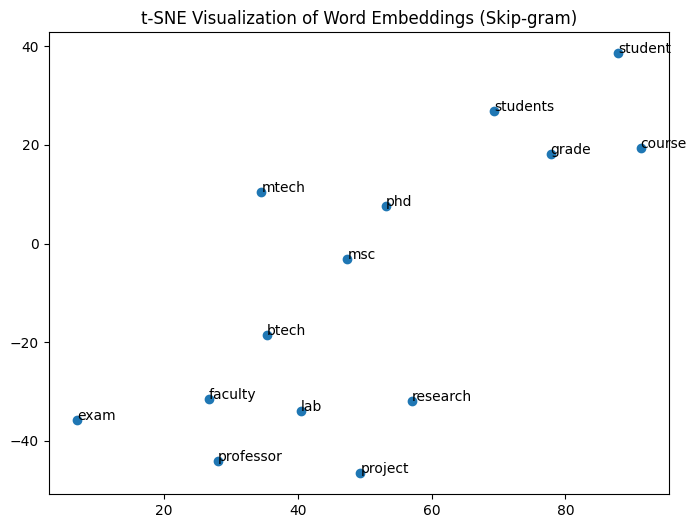

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (X[i,0], X[i,1]))

plt.title("t-SNE Visualization of Word Embeddings (Skip-gram)")
plt.show()

CBOW visulalization

In [89]:
import numpy as np

valid_words = [w for w in words if w in CBOW_model.wv]
vectors = []
for w in valid_words:
    vectors.append(CBOW_model.wv[w])
vectors = np.array(vectors)
vectors.shape

(14, 200)

In [90]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X = tsne.fit_transform(vectors)

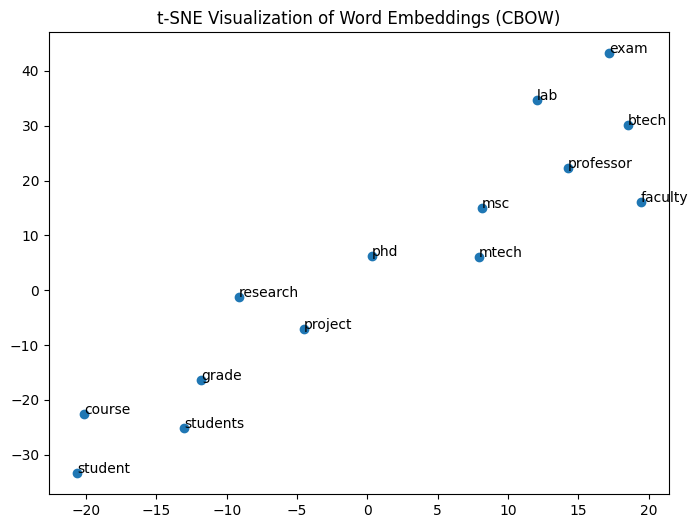

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (X[i,0], X[i,1]))

plt.title("t-SNE Visualization of Word Embeddings (CBOW)")
plt.show()